# Machine Learning Analysis of Indian Monsoon Rainfall Regimes (1979–2022)

This notebook applies unsupervised machine learning to identify spatial rainfall regimes across India using the IMD 0.25° gridded rainfall dataset.

Author: Ashwin Jayakumar

## Objective

The goal of this project is to identify spatial rainfall regimes across India during the monsoon season using machine learning.

Steps:

1. Load IMD gridded rainfall data
2. Extract JJAS monsoon rainfall
3. Compute climatological features
4. Apply KMeans clustering
5. Visualize rainfall regimes

## Dataset

Source: India Meteorological Department (IMD)

Resolution: 0.25° gridded rainfall  
Period: 1979–2022  
Temporal resolution: Daily

Only the JJAS monsoon season (June–September) is used.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import xarray as xr

ds = xr.open_dataset(
    r"D:\IISER\Project\Hazard_Data\1.IMD_Rainfall\Rainfall_79_22.nc",
    chunks={"TIME": 365}
)

rain = ds["RAINFALL"]

rain = rain.sel(TIME=rain.TIME.dt.month.isin([6,7,8,9]))

C:\Users\user\AppData\Local\Temp\ipykernel_24752\220934143.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "TIME" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


## Feature Extraction

Four rainfall statistics are computed for each grid cell:

- Mean monsoon rainfall
- Rainfall variability (standard deviation)
- Extreme rainfall intensity (95th percentile)
- Wet-day frequency (rainfall > 1 mm)

These features summarize the climatological rainfall behaviour of each location.

In [3]:
mean_rain = rain.mean("TIME")

std_rain = rain.std("TIME")

p95 = rain.quantile(0.95, dim="TIME")

wet_days = (rain > 1).sum("TIME")
from dask.diagnostics import ProgressBar

with ProgressBar():

    mean_rain = mean_rain.compute()
    std_rain = std_rain.compute()
    p95 = p95.compute()
    wet_days = wet_days.compute()

[########################################] | 100% Completed | 29.37 s
[#                                       ] | 3% Completed | 1.24 s ms

c:\Users\user\New folder\Lib\site-packages\dask\array\numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


[########################################] | 100% Completed | 28.10 s
[####                                    ] | 11% Completed | 5.59 sms

c:\Users\user\New folder\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


[########################################] | 100% Completed | 33.04 s
[########################################] | 100% Completed | 27.11 s


In [4]:
features = xr.Dataset({
    "mean": mean_rain,
    "std": std_rain,
    "p95": p95,
    "wet_days": wet_days
})

In [5]:
df = features.to_dataframe().reset_index().dropna()

print(df.shape)

(4964, 7)


## Machine Learning: KMeans Clustering

KMeans clustering groups grid cells based on rainfall characteristics.

Number of clusters: 5

Each cluster represents a distinct rainfall regime across India.

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[["mean","std","p95","wet_days"]]

X = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)

df["cluster"] = kmeans.fit_predict(X)

## Cluster Characteristics

In [24]:
df.groupby("cluster")[["mean","std","p95","wet_days"]].mean()

,mean,std,p95,wet_days
cluster,,,,
0,8.361359,16.089366,37.343521,3015.126480
1,5.204738,12.744964,27.035237,2114.894737
2,25.477585,35.786776,96.785631,4349.662500
3,13.109113,20.414338,51.169247,3802.286807
4,2.442338,8.070737,13.759461,1260.315749


## Spatial Distribution of Rainfall Regimes

The clusters are visualized spatially across India using the country boundary shapefile.

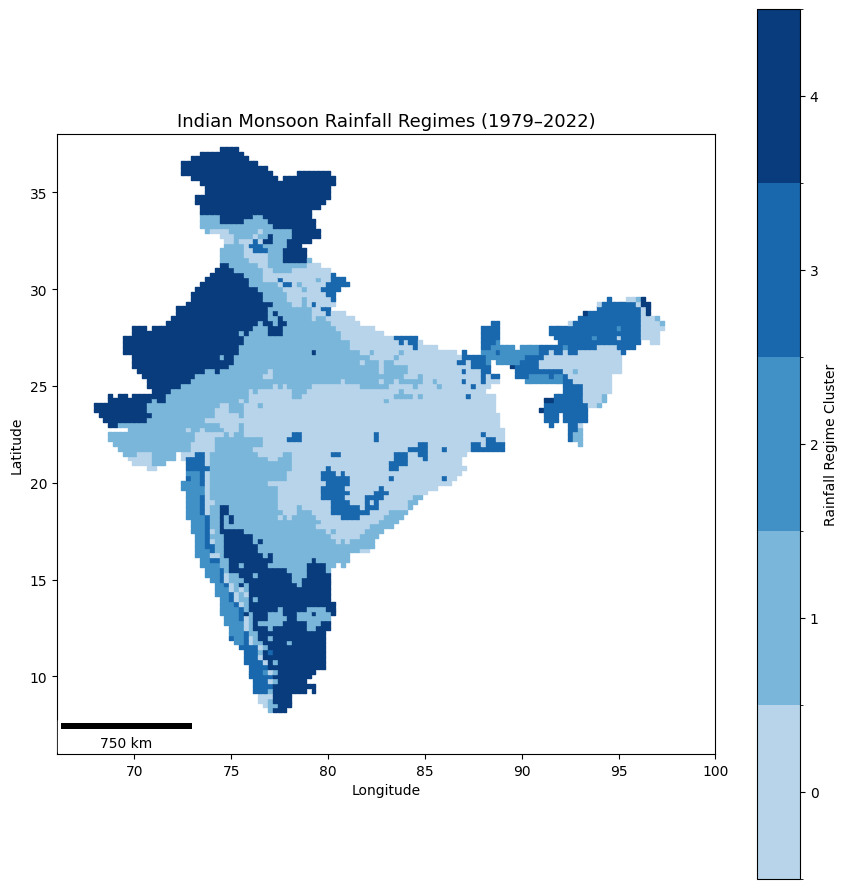

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import pandas as pd

# ---------------------------------------
# Load India boundary
# ---------------------------------------

india = gpd.read_file(
    r"D:\IISER\Project\Maps\India\India_Country_Boundary\India_Country_Boundary.shp"
)

# ---------------------------------------
# Convert dataframe to GeoDataFrame
# ---------------------------------------

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["LONGITUDE"], df["LATITUDE"]),
    crs="EPSG:4326"
)

# ---------------------------------------
# Discrete Blues colormap
# ---------------------------------------

colors = plt.cm.Blues(np.linspace(0.3, 0.95, 5))

cmap = ListedColormap(colors)

bounds = [-0.5,0.5,1.5,2.5,3.5,4.5]

norm = BoundaryNorm(bounds, cmap.N)

# ---------------------------------------
# Plot
# ---------------------------------------

fig, ax = plt.subplots(figsize=(9,9))

# rainfall clusters (square markers)
sc = ax.scatter(
    gdf["LONGITUDE"],
    gdf["LATITUDE"],
    c=gdf["cluster"],
    cmap=cmap,
    norm=norm,
    marker="s",
    s=8
)

# India boundary plotted LAST so it stays visible
india.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5,
    zorder=3
)

# ---------------------------------------
# Colorbar (categorical)
# ---------------------------------------

cbar = plt.colorbar(
    sc,
    ax=ax,
    boundaries=bounds,
    ticks=[0,1,2,3,4],
    spacing="proportional"
)

cbar.set_label("Rainfall Regime Cluster")

# ---------------------------------------
# Map styling
# ---------------------------------------

ax.set_title("Indian Monsoon Rainfall Regimes (1979–2022)", fontsize=13)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_xlim(66,100)
ax.set_ylim(6,38)

# ---------------------------------------
# Scale bar
# ---------------------------------------

scalebar = ScaleBar(
    dx=111000,
    location="lower left",
    length_fraction=0.25
)

ax.add_artist(scalebar)

plt.tight_layout()

plt.show()

## Conclusion

Machine learning clustering identified five rainfall regimes across India based on long-term monsoon rainfall characteristics.

The approach demonstrates how climate datasets can be analysed using machine learning and geospatial visualization techniques.

Tools used:
- Python
- Xarray
- Scikit-learn
- GeoPandas
- Matplotlib

In [27]:
import xarray
import numpy
import pandas
import matplotlib
import geopandas
import sklearn
import dask
import shapely
import matplotlib_scalebar

print("xarray:", xarray.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("matplotlib:", matplotlib.__version__)
print("geopandas:", geopandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("dask:", dask.__version__)
print("shapely:", shapely.__version__)
print("matplotlib-scalebar:", matplotlib_scalebar.__version__)

xarray: 2025.6.1
numpy: 2.3.1
pandas: 2.3.0
matplotlib: 3.10.3
geopandas: 1.1.2
scikit-learn: 1.8.0
dask: 2025.12.0
shapely: 2.1.2
matplotlib-scalebar: 0.9.0
